# Atlantic Haven Hotels — Notebook final

**Objectif :** prédire `reservation_annulee` (1 = annulation) avec une probabilité et une décision binaire au seuil optimisé.

**Métrique principale :** F1-score de la classe positive.

**Contrainte critique :** validation temporelle uniquement (pas de `train_test_split` aléatoire, pas de `shuffle=True`, pas d'usage du test pour le réglage).

Ce notebook est exécutable de bout en bout depuis un noyau vierge et régénère `submission.csv`.


## 0. Setup

In [1]:
from pathlib import Path
import sys
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.utils import (
    RANDOM_STATE, TARGET_COL, TIME_COL, ID_COL, RAW_DIR, PROCESSED_DIR,
    FIGURES_DIR, MODELS_DIR, PROJECT_ROOT, load_raw_data, set_seed, ensure_dirs, save_figure,
)
from src.features import engineer_features, FEATURE_GROUPS, leakage_checklist
from src.validation import temporal_holdout, optimize_threshold, evaluate_predictions
from src.preprocessing import prepare_xy, get_feature_columns
from src.modeling import (
    compare_models, rebuild_pipeline, assert_submission,
    build_logistic_pipeline, fit_and_score,
)

set_seed(RANDOM_STATE)
ensure_dirs()
print("PROJECT_ROOT =", PROJECT_ROOT)
print("RANDOM_STATE =", RANDOM_STATE)


PROJECT_ROOT = /home/dev/ROGELLA-EXAMEN/atlantic-haven-hotels
RANDOM_STATE = 42


## 1. Chargement et audit des données

In [2]:
train_raw, test_raw = load_raw_data(parse_dates=True, sort_train=False)
test_order_ids = test_raw[ID_COL].tolist()

print("Train:", train_raw.shape, "| Test:", test_raw.shape)
print("Colonnes train:", list(train_raw.columns))
print("\nTypes:")
display(train_raw.dtypes.to_frame("dtype"))

print("\nPériode date_reservation train:", train_raw[TIME_COL].min().date(), "→", train_raw[TIME_COL].max().date())
print("Période date_reservation test :", test_raw[TIME_COL].min().date(), "→", test_raw[TIME_COL].max().date())
print("Période date_arrivee train:", train_raw["date_arrivee"].min().date(), "→", train_raw["date_arrivee"].max().date())

cancel_rate = train_raw[TARGET_COL].mean()
print(f"\nTaux d'annulation global (train): {cancel_rate:.4f}")
display(train_raw[TARGET_COL].value_counts().to_frame("count"))

miss = train_raw.isna().sum()
print("\nValeurs manquantes (train):")
display(miss[miss > 0].to_frame("n_missing"))

print("Doublons reservation_id train:", train_raw[ID_COL].duplicated().sum())
print("Doublons reservation_id test :", test_raw[ID_COL].duplicated().sum())
print("IDs communs train/test:", len(set(train_raw[ID_COL]) & set(test_raw[ID_COL])))
print("Arrivées avant réservation:", (train_raw["date_arrivee"] < train_raw[TIME_COL]).sum())

# Catégories présentes dans le test mais absentes du train
unseen = {}
for c in train_raw.columns:
    if c in test_raw.columns and c not in {ID_COL, TARGET_COL, "date_reservation", "date_arrivee"}:
        if pd.api.types.is_string_dtype(train_raw[c]) or train_raw[c].dtype == object:
            miss_cats = set(test_raw[c].dropna().astype(str)) - set(train_raw[c].dropna().astype(str))
            if miss_cats:
                unseen[c] = sorted(miss_cats)
print("Catégories inconnues (test \\ train):", unseen)


Train: (8000, 34) | Test: (2000, 33)
Colonnes train: ['reservation_id', 'date_reservation', 'date_arrivee', 'region_hotel', 'ville', 'type_destination', 'hotel_id', 'categorie_hotel', 'segment_client', 'marche_origine', 'canal_reservation', 'moyen_transport', 'delai_reservation_jours', 'nuits', 'adultes', 'enfants', 'chambres', 'formule_repas', 'tarif_remboursable', 'type_acompte', 'prix_moyen_nuit_eur', 'remise_pct', 'montant_total_eur', 'client_type', 'reservations_passees', 'annulations_passees', 'demandes_speciales', 'modifications_reservation', 'jours_liste_attente', 'evenement_majeur', 'haute_saison_regionale', 'arrivee_weekend', 'agent_id', 'reservation_annulee']

Types:


,dtype
reservation_id,str
date_reservation,datetime64[us]
date_arrivee,datetime64[us]
region_hotel,str
ville,str
type_destination,str
hotel_id,str
categorie_hotel,int64
segment_client,str
marche_origine,str



Période date_reservation train: 2023-01-01 → 2025-05-24
Période date_reservation test : 2025-05-24 → 2025-12-31
Période date_arrivee train: 2023-01-04 → 2026-06-02

Taux d'annulation global (train): 0.2584


,count
reservation_annulee,
0,5933
1,2067



Valeurs manquantes (train):

,n_missing
marche_origine,191
enfants,355
prix_moyen_nuit_eur,193
demandes_speciales,157
agent_id,3354


Doublons reservation_id train: 0
Doublons reservation_id test : 0
IDs communs train/test: 0
Arrivées avant réservation: 0


Catégories inconnues (test \ train): {'canal_reservation': ['assistant_vocal']}


## 2. EDA — scénarios d'annulation et temporalité

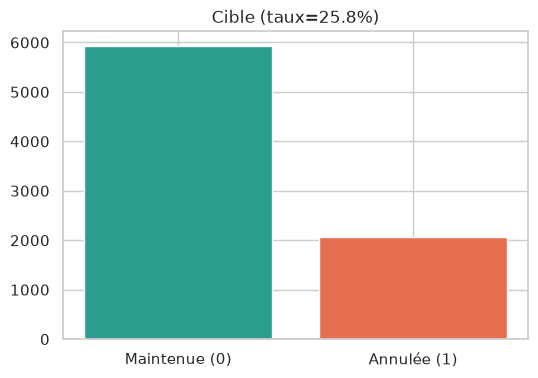

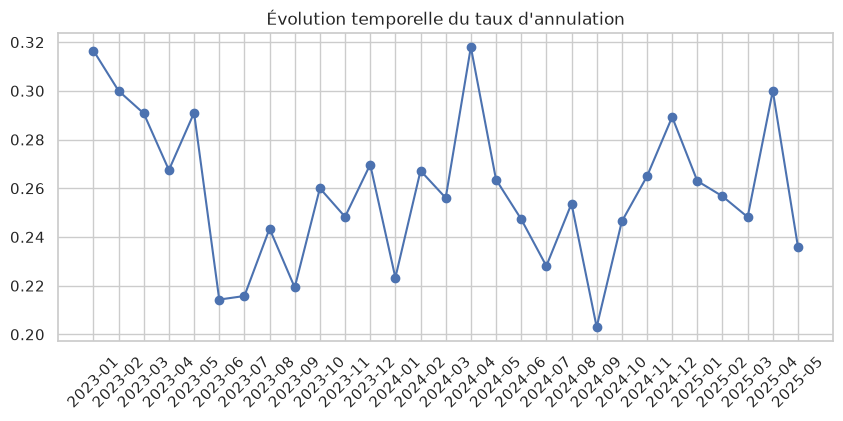


=== tarif_remboursable ===


,mean,count
tarif_remboursable,,
oui,0.313,5481
non,0.140,2519



=== type_acompte ===


,mean,count
type_acompte,,
aucun,0.340,3835
partiel,0.230,2613
total,0.104,1552



=== canal_reservation ===


,mean,count
canal_reservation,,
plateforme_en_ligne,0.304,3321
agence,0.278,1325
telephone,0.229,719
site_hotel,0.215,2013
entreprise,0.145,622



=== type_destination ===


,mean,count
type_destination,,
urbaine_cotiere,0.284,782
insulaire_balneaire,0.281,327
insulaire_mixte,0.270,619
urbaine_culturelle,0.264,1349
urbaine_littorale,0.261,1013
affaires_lacs,0.255,1100
montagne,0.250,661
culturelle_rurale,0.248,978
balneaire_rurale,0.240,525


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = train_raw[TARGET_COL].value_counts().sort_index()
ax.bar(["Maintenue (0)", "Annulée (1)"], counts.values, color=["#2a9d8f", "#e76f51"])
ax.set_title(f"Cible (taux={cancel_rate:.1%})")
save_figure(fig, "nb_final_cible.png"); plt.show()

tmp = train_raw.copy()
tmp["mois"] = tmp[TIME_COL].dt.to_period("M").astype(str)
monthly = tmp.groupby("mois")[TARGET_COL].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly.values, marker="o")
ax.set_title("Évolution temporelle du taux d'annulation")
ax.tick_params(axis="x", rotation=45)
save_figure(fig, "nb_final_temporel.png"); plt.show()

for col in ["tarif_remboursable", "type_acompte", "canal_reservation", "type_destination"]:
    rates = train_raw.groupby(col)[TARGET_COL].agg(["mean", "count"]).sort_values("mean", ascending=False)
    print(f"\n=== {col} ===")
    display(rates.round(3))


## 3. Feature engineering

Variables dérivées (dates, séjour, prix, historique row-wise, interactions).
Aucune utilisation de la cible ni d'information future.


In [4]:
display(pd.DataFrame(leakage_checklist()))
train_fe = engineer_features(train_raw)
test_fe = engineer_features(test_raw)
print("Train après FE:", train_fe.shape)
print("Nouvelles colonnes (extrait):", [c for c in train_fe.columns if c not in train_raw.columns][:15])


,groupe,variables,utilise_cible,utilise_futur,commentaire
0,dates,"annee_reservation, mois_reservation, mois_arri...",False,False,Calculées uniquement à partir des colonnes dis...
1,sejour,"taille_groupe, enfants_presents, personnes_par...",False,False,Calculées uniquement à partir des colonnes dis...
2,prix,"prix_par_personne, prix_par_nuit_calc, montant...",False,False,Calculées uniquement à partir des colonnes dis...
3,historique,"taux_annulation_passe, client_jamais_reserve, ...",False,False,Calculées uniquement à partir des colonnes dis...
4,interactions,"lead_x_remboursable, saison_x_nuits, nouveau_x...",False,False,Calculées uniquement à partir des colonnes dis...


Train après FE: (8000, 64)
Nouvelles colonnes (extrait): ['annee_reservation', 'mois_reservation', 'mois_arrivee', 'trimestre_arrivee', 'jour_semaine_arrivee', 'arrivee_weekend_calc', 'saison_arrivee', 'delai_calcule', 'delai_court', 'delai_long', 'taille_groupe', 'enfants_presents', 'personnes_par_chambre', 'nuits_par_chambre', 'sejour_long']


## 4. Validation temporelle

- Colonne: `date_reservation`
- Holdout 80 % anciens / 20 % plus récents
- Aucun shuffle


In [5]:
split = temporal_holdout(train_fe, time_col=TIME_COL, val_ratio=0.20, verbose=True)
tr, va = split.train, split.valid
assert tr[TIME_COL].max() <= va[TIME_COL].min()
print("Contrôle anti-mélange: OK")


=== Validation temporelle (holdout) ===
Train : 6,400 lignes | 2023-01-01 → 2024-11-28 | taux annulation = 0.2559
Valid : 1,600 lignes | 2024-11-28 → 2025-05-24 | taux annulation = 0.2681
Contrôle anti-mélange: OK


## 5. Baseline — régression logistique

In [6]:
X_tr, y_tr = prepare_xy(tr)
X_va, y_va = prepare_xy(va)
num_cols, cat_cols = get_feature_columns(tr)
print(f"Features: {len(num_cols)} numériques, {len(cat_cols)} catégorielles")

pipe_lr = build_logistic_pipeline(num_cols, cat_cols)
res_lr = fit_and_score(pipe_lr, X_tr, y_tr, X_va, y_va, "logistic_regression")

print("=== Seuil 0.5 ===")
print(f"F1={res_lr['metrics_05']['f1']:.4f} P={res_lr['metrics_05']['precision']:.4f} R={res_lr['metrics_05']['recall']:.4f}")
print("=== Seuil optimisé ===")
m = res_lr["metrics_opt"]
print(f"seuil={m['threshold']:.2f} F1={m['f1']:.4f} P={m['precision']:.4f} R={m['recall']:.4f} PR-AUC={m['pr_auc']:.4f} ROC-AUC={m['roc_auc']:.4f}")
print(m["classification_report"])
print("Matrice de confusion (seuil opt):", m["confusion_matrix"])
baseline_f1 = m["f1"]
baseline_thr = m["threshold"]


Features: 46 numériques, 13 catégorielles


=== Seuil 0.5 ===
F1=0.4523 P=0.3600 R=0.6084
=== Seuil optimisé ===
seuil=0.43 F1=0.4759 P=0.3489 R=0.7483 PR-AUC=0.3932 ROC-AUC=0.6544
              precision    recall  f1-score   support

           0     0.8412    0.4885    0.6180      1171
           1     0.3489    0.7483    0.4759       429

    accuracy                         0.5581      1600
   macro avg     0.5950    0.6184    0.5470      1600
weighted avg     0.7092    0.5581    0.5799      1600

Matrice de confusion (seuil opt): [[572, 599], [108, 321]]


## 6. Ablation du feature engineering

In [7]:
from src.modeling import build_logistic_pipeline

base_cols = [
    c for c in tr.columns
    if c not in {ID_COL, "date_reservation", "date_arrivee", TARGET_COL, "agent_id"}
    and c not in sum(FEATURE_GROUPS.values(), [])
]
rows = []
configs = {"sans_fe": base_cols}
for g, feats in FEATURE_GROUPS.items():
    configs[f"groupe_{g}"] = base_cols + [f for f in feats if f in tr.columns]
configs["toutes_fe"] = base_cols + [f for f in sum(FEATURE_GROUPS.values(), []) if f in tr.columns]

for name, cols in configs.items():
    use = [c for c in cols if c in tr.columns]
    tmp = tr[use + [TARGET_COL]]
    n, c = get_feature_columns(tmp)
    pipe = build_logistic_pipeline(n, c)
    r = fit_and_score(pipe, tr[use], tr[TARGET_COL].astype(int), va[use], va[TARGET_COL].astype(int), name)
    rows.append({"config": name, "n_features": len(use), "f1": r["f1"], "threshold": r["threshold"]})
    print(f"{name}: F1={r['f1']:.4f}")

ablation = pd.DataFrame(rows)
ablation["delta_f1"] = ablation["f1"] - ablation.loc[ablation["config"]=="sans_fe", "f1"].iloc[0]
display(ablation.round(4))
ablation.to_csv(PROCESSED_DIR / "ablation_features.csv", index=False)


sans_fe: F1=0.4736


groupe_dates: F1=0.4710


groupe_sejour: F1=0.4712


groupe_prix: F1=0.4711


groupe_historique: F1=0.4758


groupe_interactions: F1=0.4730


toutes_fe: F1=0.4759


,config,n_features,f1,threshold,delta_f1
0,sans_fe,29,0.4736,0.39,0.0000
1,groupe_dates,39,0.4710,0.38,-0.0026
2,groupe_sejour,34,0.4712,0.39,-0.0024
3,groupe_prix,35,0.4711,0.39,-0.0025
4,groupe_historique,32,0.4758,0.40,0.0022
5,groupe_interactions,35,0.4730,0.39,-0.0006
6,toutes_fe,59,0.4759,0.43,0.0023


## 7. Comparaison des modèles (même protocole temporel)

In [8]:
comparison = compare_models(tr, va)
results = comparison["results"]
best_name = comparison["best_name"]
best = results[best_name]

rows = []
for name, r in results.items():
    m = r["metrics_opt"]
    rows.append({
        "modele": name,
        "f1": m["f1"],
        "precision": m["precision"],
        "rappel": m["recall"],
        "pr_auc": m["pr_auc"],
        "roc_auc": m["roc_auc"],
        "seuil": m["threshold"],
        "temps_s": r["train_time_sec"],
        "f1_seuil_05": r["metrics_05"]["f1"],
    })
metrics_table = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(metrics_table.round(4))
metrics_table.to_csv(PROCESSED_DIR / "model_comparison.csv", index=False)
print(f"\n>>> Modèle final retenu: {best_name} | F1={best['f1']:.4f} | seuil={best['threshold']:.2f}")



--- Entraînement : logistic_regression ---


logistic_regression: thr=0.43 F1=0.4759 P=0.3489 R=0.7483 PR-AUC=0.3932 ROC-AUC=0.6544 time=2.5s

--- Entraînement : random_forest ---


random_forest: thr=0.33 F1=0.4775 P=0.3396 R=0.8042 PR-AUC=0.3548 ROC-AUC=0.6409 time=3.3s

--- Entraînement : hist_gradient_boosting ---


hist_gradient_boosting: thr=0.21 F1=0.4577 P=0.3166 R=0.8252 PR-AUC=0.3591 ROC-AUC=0.6269 time=3.2s

--- Entraînement : xgboost ---


xgboost: thr=0.17 F1=0.4583 P=0.3118 R=0.8648 PR-AUC=0.3542 ROC-AUC=0.6264 time=2.7s

--- Entraînement : lightgbm ---


lightgbm: thr=0.13 F1=0.4558 P=0.3094 R=0.8648 PR-AUC=0.3536 ROC-AUC=0.6220 time=3.0s


,modele,f1,precision,rappel,pr_auc,roc_auc,seuil,temps_s,f1_seuil_05
1,random_forest,0.4775,0.3396,0.8042,0.3548,0.6409,0.33,3.2546,0.3793
0,logistic_regression,0.4759,0.3489,0.7483,0.3932,0.6544,0.43,2.5087,0.4523
3,xgboost,0.4583,0.3118,0.8648,0.3542,0.6264,0.17,2.7133,0.3923
2,hist_gradient_boosting,0.4577,0.3166,0.8252,0.3591,0.6269,0.21,3.2170,0.4000
4,lightgbm,0.4558,0.3094,0.8648,0.3536,0.6220,0.13,2.9790,0.3750



>>> Modèle final retenu: random_forest | F1=0.4775 | seuil=0.33


## 8. Optimisation du seuil (validation uniquement)

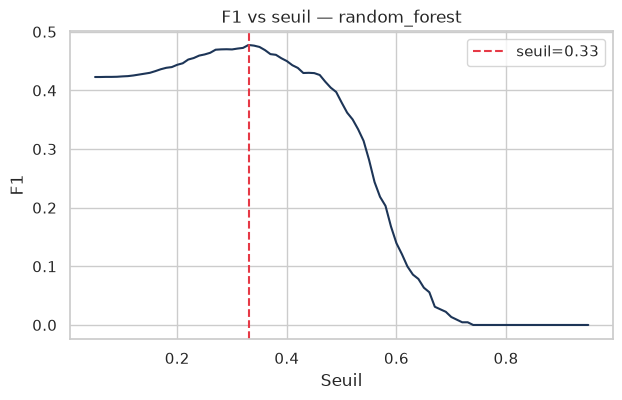

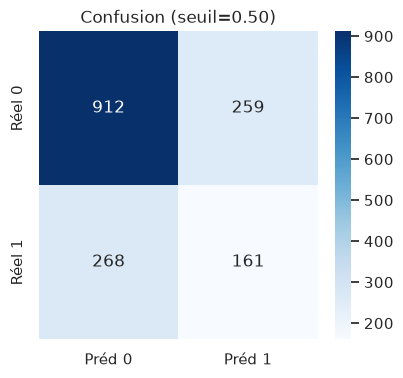

Seuil 0.50: FP=259 FN=268 TP=161 TN=912


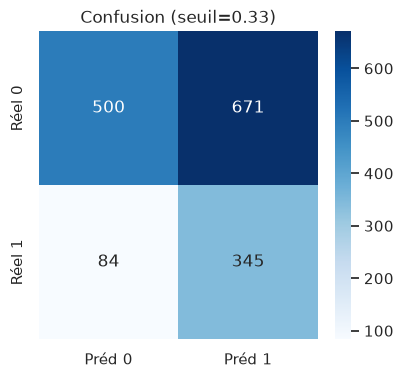

Seuil 0.33: FP=671 FN=84 TP=345 TN=500


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(best["threshold_grid"], best["f1_grid"], color="#1d3557")
ax.axvline(best["threshold"], color="#e63946", ls="--", label=f"seuil={best['threshold']:.2f}")
ax.set_xlabel("Seuil"); ax.set_ylabel("F1"); ax.set_title(f"F1 vs seuil — {best_name}")
ax.legend(); save_figure(fig, "nb_final_seuil.png"); plt.show()

for label, metrics in [("0.50", best["metrics_05"]), (f"{best['threshold']:.2f}", best["metrics_opt"])]:
    cm = np.array(metrics["confusion_matrix"])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Préd 0","Préd 1"], yticklabels=["Réel 0","Réel 1"])
    ax.set_title(f"Confusion (seuil={label})")
    fname = f"nb_final_cm_{label.replace('.', '_')}.png"
    save_figure(fig, fname)
    plt.show()
    print(f"Seuil {label}: FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]} TN={cm[0,0]}")


## 9. Analyse d'erreurs et importance

Faux positifs (prédit annulé, séjour maintenu):


,reservation_id,region_hotel,type_destination,canal_reservation,tarif_remboursable,type_acompte,delai_reservation_jours,client_type,proba
7610,R005310,Sicilia,insulaire_mixte,agence,oui,aucun,98,nouveau,0.759798
6612,R000682,Lazio,urbaine_culturelle,plateforme_en_ligne,oui,aucun,93,nouveau,0.746459
6857,R001206,Sicilia,insulaire_mixte,plateforme_en_ligne,oui,aucun,71,nouveau,0.735342
7057,R002897,Veneto,urbaine_littorale,plateforme_en_ligne,oui,aucun,91,nouveau,0.735287
7054,R006211,Trentino-Alto_Adige,montagne,plateforme_en_ligne,oui,aucun,84,fidele,0.731656


Faux négatifs (annulation non détectée):


,reservation_id,region_hotel,type_destination,canal_reservation,tarif_remboursable,type_acompte,delai_reservation_jours,client_type,proba
7733,R009204,Toscana,culturelle_rurale,site_hotel,non,total,29,fidele,0.103192
7984,R001185,Liguria,littorale,site_hotel,non,total,34,nouveau,0.110677
7978,R001223,Lombardia,affaires_lacs,entreprise,non,total,41,nouveau,0.143141
7021,R001479,Trentino-Alto_Adige,montagne,agence,non,partiel,25,fidele,0.146285
6482,R002592,Sicilia,insulaire_mixte,entreprise,non,partiel,24,fidele,0.147127


,region,n,f1,cancel_rate
0,Campania,169,0.402685,0.230769
1,Lazio,258,0.444444,0.228682
7,Toscana,188,0.447059,0.260638
5,Sardegna,67,0.466667,0.283582
9,Veneto,214,0.468750,0.271028
4,Puglia,99,0.481013,0.252525
2,Liguria,127,0.482143,0.267717
3,Lombardia,216,0.505263,0.277778
8,Trentino-Alto_Adige,141,0.540146,0.290780
6,Sicilia,121,0.564885,0.371901


,feature,importance
16,type_acompte,0.067817
56,acompte_x_delai,0.048294
15,tarif_remboursable,0.039711
49,sans_acompte,0.026655
53,lead_x_remboursable,0.019622
48,tarif_flexible,0.013270
7,canal_reservation,0.008448
23,demandes_speciales,0.008390
47,remise_forte,0.007014
21,reservations_passees,0.005948


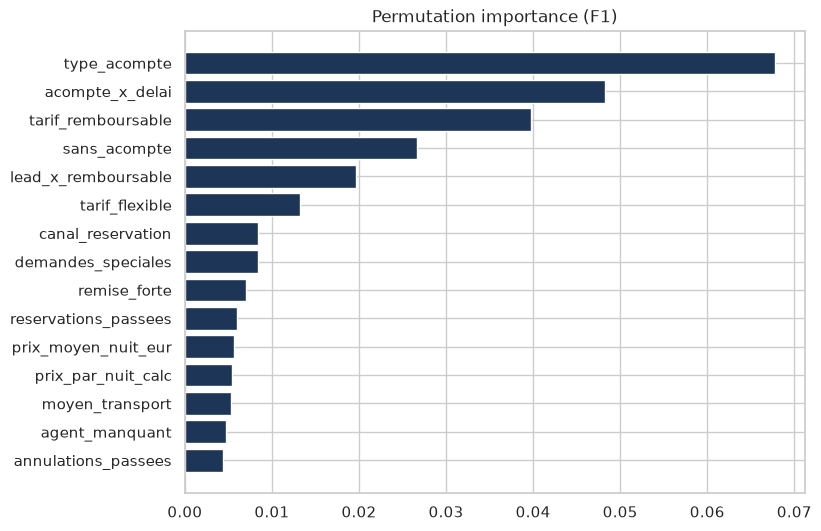

In [10]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

va_err = va.copy()
va_err["proba"] = best["proba_valid"]
va_err["pred"] = (va_err["proba"] >= best["threshold"]).astype(int)

fp = va_err[(va_err[TARGET_COL]==0) & (va_err["pred"]==1)].nlargest(5, "proba")
fn = va_err[(va_err[TARGET_COL]==1) & (va_err["pred"]==0)].nsmallest(5, "proba")
cols_show = [ID_COL,"region_hotel","type_destination","canal_reservation","tarif_remboursable","type_acompte","delai_reservation_jours","client_type","proba"]
print("Faux positifs (prédit annulé, séjour maintenu):")
display(fp[cols_show])
print("Faux négatifs (annulation non détectée):")
display(fn[cols_show])

# Perf par région
region_rows = []
for region, g in va_err.groupby("region_hotel"):
    if len(g) < 40:
        continue
    region_rows.append({"region": region, "n": len(g), "f1": f1_score(g[TARGET_COL], g["pred"], zero_division=0), "cancel_rate": g[TARGET_COL].mean()})
display(pd.DataFrame(region_rows).sort_values("f1"))

pi = permutation_importance(best["pipeline"], X_va, y_va, n_repeats=5, random_state=RANDOM_STATE, scoring="f1", n_jobs=-1)
imp = pd.DataFrame({"feature": list(X_va.columns), "importance": pi.importances_mean}).sort_values("importance", ascending=False)
display(imp.head(15))
fig, ax = plt.subplots(figsize=(8, 6))
top = imp.head(15).iloc[::-1]
ax.barh(top["feature"], top["importance"], color="#1d3557")
ax.set_title("Permutation importance (F1)")
save_figure(fig, "nb_final_importance.png"); plt.show()


## 10. Réentraînement final et submission.csv

In [11]:
# Réentraînement sur TOUT le train — seuil figé depuis la validation
X_full, y_full = prepare_xy(train_fe)
final_pipe = rebuild_pipeline(best_name, comparison["num_cols"], comparison["cat_cols"], comparison["scale_pos_weight"])
t0 = time.perf_counter()
final_pipe.fit(X_full, y_full)
print(f"Entraînement final: {time.perf_counter()-t0:.1f}s")

joblib.dump({"pipeline": final_pipe, "threshold": best["threshold"], "model_name": best_name}, MODELS_DIR / "modele_final.pkl")

# Ordre original du fichier test STRICTEMENT conservé
test_ordered = pd.read_csv(RAW_DIR / "reservations_test.csv")
test_ordered["date_reservation"] = pd.to_datetime(test_ordered["date_reservation"])
test_ordered["date_arrivee"] = pd.to_datetime(test_ordered["date_arrivee"])
X_test = prepare_xy(engineer_features(test_ordered))[0]
proba_test = final_pipe.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= best["threshold"]).astype(int)

submission = pd.DataFrame({
    "reservation_id": test_ordered[ID_COL],
    "probabilite_annulation": np.round(proba_test, 6),
    "reservation_annulee": pred_test,
})
assert_submission(submission, test_ordered, RAW_DIR / "sample_submission.csv")
assert submission[ID_COL].tolist() == test_order_ids

out = PROJECT_ROOT / "submission.csv"
submission.to_csv(out, index=False)
print(f"Écrit: {out} | lignes={len(submission)} | taux préd. positifs={pred_test.mean():.3f}")
display(submission.head())


Entraînement final: 3.5s


Écrit: /home/dev/ROGELLA-EXAMEN/atlantic-haven-hotels/submission.csv | lignes=2000 | taux préd. positifs=0.628


,reservation_id,probabilite_annulation,reservation_annulee
0,R002267,0.296701,0
1,R002852,0.226598,0
2,R003752,0.574951,1
3,R009926,0.490161,1
4,R000141,0.459359,1


## 11. Synthèse des résultats

In [12]:
payload = {
    "best_model": best_name,
    "threshold": float(best["threshold"]),
    "best_f1": float(best["f1"]),
    "baseline_lr_f1": float(baseline_f1),
    "baseline_lr_threshold": float(baseline_thr),
    "split": {
        "train_period": list(split.train_period),
        "valid_period": list(split.valid_period),
        "train_n": len(tr),
        "valid_n": len(va),
    },
    "metrics_table": metrics_table.to_dict(orient="records"),
    "ablation": ablation.to_dict(orient="records"),
}
print(json.dumps(payload, indent=2, ensure_ascii=False))
print("\nContrôles finaux: OK — submission conforme, seeds fixées, validation temporelle respectée.")


{
  "best_model": "random_forest",
  "threshold": 0.32999999999999996,
  "best_f1": 0.47750865051903113,
  "baseline_lr_f1": 0.4759080800593032,
  "baseline_lr_threshold": 0.42999999999999994,
  "split": {
    "train_period": [
      "2023-01-01",
      "2024-11-28"
    ],
    "valid_period": [
      "2024-11-28",
      "2025-05-24"
    ],
    "train_n": 6400,
    "valid_n": 1600
  },
  "metrics_table": [
    {
      "modele": "random_forest",
      "f1": 0.47750865051903113,
      "precision": 0.3395669291338583,
      "rappel": 0.8041958041958042,
      "pr_auc": 0.35480700123511094,
      "roc_auc": 0.6409121763519714,
      "seuil": 0.32999999999999996,
      "temps_s": 3.254619030019967,
      "f1_seuil_05": 0.3792697290930506
    },
    {
      "modele": "logistic_regression",
      "f1": 0.4759080800593032,
      "precision": 0.34891304347826085,
      "rappel": 0.7482517482517482,
      "pr_auc": 0.39320178823936186,
      "roc_auc": 0.6544363692100669,
      "seuil": 0.4299999